# Google Play Store — Exploratory Data Analysis

**Showcasing opportunity in the Google Playstore**

**Author:** Reuben Cervantes 

**Dataset:** Google Play Store Apps (10,800 apps, 13 columns)

## Why this project
App stores are winner take all markets, so understanding what separates a
successful app from an ignored one is a real product question.

This notebook covers the foundation loading, inspecting, auditing, cleaning
data, and a chart to revealing where the opportunity lies.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import duckdb 

# Show all columns and don't cut off wide text when printing tables
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("pandas version:", pd.__version__)

df = pd.read_csv("../Data/google_play_store_dataset.csv")

# .shape returns (rows, columns)
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")

pandas version: 3.0.3
Rows: 10,841   Columns: 13


## First look at the data

Before trusting anything, we eyeball the table and its structure:
- `df.head()` — the first 5 rows, so we see what real values look like
- `df.info()` — every column, its non-null count, and its **data type** (`dtype`)
- `df.describe()` — summary statistics for numeric columns

Watch the `dtype` column in `.info()` — that's where the first problems hide.

In [38]:
df.head()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [40]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


## Data-quality audit

`isnull().sum()` counts blanks per column. `Rating` is missing for many apps
(ones nobody has rated yet) we'll make a deliberate decision about those rather
than silently dropping them.

In [41]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

## Duplicate rows
The dataset was scraped, so the same app can appear multiple times.
`duplicated()` flags exact repeat rows; summing gives the count.

In [42]:
print("Exact duplicate rows:", df.duplicated().sum())

# Duplicate app names are even more common (same app, slightly different scrape)
print("Duplicate app names:", df["App"].duplicated().sum())

Exact duplicate rows: 483
Duplicate app names: 1181


## The corrupted row 
Ratings are on a 1–5 scale, so any rating above 5 is impossible. Filtering for
`Rating > 5` surfaces one row where a missing `Category` shifted every field one
column to the left — its "rating" is actually an install count.

In [43]:
# to_numeric(..., errors="coerce") turns non-numbers into NaN so the compare is safe
bad_rating = df[pd.to_numeric(df["Rating"], errors="coerce") > 5]
bad_rating

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [44]:
for col in ["Installs", "Price", "Reviews", "Size"]:
    print(f"{col:10s} sample -> {df[col].unique()[:5]}")

Installs   sample -> <StringArray>
['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+']
Length: 5, dtype: str
Price      sample -> <StringArray>
['0', '$4.99', '$3.99', '$6.99', '$1.49']
Length: 5, dtype: str
Reviews    sample -> <StringArray>
['159', '967', '87510', '215644', '167']
Length: 5, dtype: str
Size       sample -> <StringArray>
['19M', '14M', '8.7M', '25M', '2.8M']
Length: 5, dtype: str


## Clean the data

Now we fix everything we found, in order. We work on a **copy** so the original
stays intact — if we make a mistake, we re-run from the raw load without
re-downloading.

In [45]:
clean = df.copy()
start_rows = len(clean)


### Drop the corrupted row
It's a single bad record, so removing it is the honest fix. `.drop()` removes it
by its index label.

In [46]:
corrupt_index = df[pd.to_numeric(df["Rating"], errors="coerce") > 5].index
clean = clean.drop(index=corrupt_index)
print("Dropped", len(corrupt_index), "corrupted row(s)")  # Only 1 row in this dataset

Dropped 1 corrupted row(s)


### Remove duplicates


In [47]:
clean = clean.drop_duplicates()
print("Rows after exact de-dup:", len(clean))   # 10,357 


Rows after exact de-dup: 10357


### Convert text columns into real numbers
`Installs`, `Price`, and `Reviews` were scraped as text with symbols
(`"10,000+"`, `"$4.99"`), so pandas can't do math on them yet. We strip the
symbols and cast each to a numeric type. We also rebuild `Type` from `Price` so
it can't disagree with the actual price.

In [48]:
# Installs: "10,000+" -> 10000
clean["Installs"] = (clean["Installs"].astype(str)
                       .str.replace(",", "", regex=False)
                       .str.replace("+", "", regex=False)
                       .astype(int))

# Price: "$4.99" -> 4.99 ; "0" stays 0.0
clean["Price"] = (clean["Price"].astype(str)
                    .str.replace("$", "", regex=False)
                    .astype(float))

# Reviews came in as text too
clean["Reviews"] = clean["Reviews"].astype(int)

# Rebuild Type from Price so the two can never contradict each other
clean["Type"] = np.where(clean["Price"] > 0, "Paid", "Free")

### De-duplicate app names

Same app name appears more than once with different review counts. Sorted by reviews descending before dropping duplicates
so keep='first' keeps the most current record of each app name rather than an arbitrary one.

In [49]:
clean = (clean.sort_values(
             ["Reviews", "Installs", "App"],          # explicit, total ordering
             ascending=[False, False, True],
             kind="stable")                            # reproducible tie-breaking
         .drop_duplicates(subset="App", keep="first"))
print("Rows after app-name de-dup:", len(clean))       # 9,659

Rows after app-name de-dup: 9659


### Cleaning summary
A quick before/after so anyone reading can see exactly what we removed and trust
the table that follows. We keep the missing `Rating` values rather than imputing
them — filling 1,400+ blanks with the mean would fabricate quality signal we
don't actually have — and simply exclude them where a rating is required.

In [50]:
print(f"Started with {start_rows:,} rows")
print(f"Ended with   {len(clean):,} rows")
print(f"Removed      {start_rows - len(clean):,} rows "
      f"({(start_rows - len(clean)) / start_rows:.1%})")

Started with 10,841 rows
Ended with   9,659 rows
Removed      1,182 rows (10.9%)


## Question 1 — Where's the market opportunity?

A team deciding what kind of app to build wants categories with **high demand but
low competition**. We measure each category on two axes:

- **Demand** — average installs per app (how much traffic a typical app captures)
- **Competition** — how many apps already exist in that category

Categories with high demand and few competitors are the opening; categories
crammed with apps that each capture little are already saturated.

To show SQL alongside pandas, we run this aggregation in **DuckDB**, which queries
the DataFrame directly.

### Reading the table
The top of the list is striking: **Communication** apps average ~35M installs
each from only 315 apps, and **Social** and **Video Players** show the same
pattern — enormous demand concentrated among relatively few apps. That's the
profile of an opportunity. We'll see the flip side (saturated categories) once we
plot competition against demand.

In [51]:
cat = duckdb.query("""
    SELECT Category,
           COUNT(*)             AS num_apps,      -- competition
           ROUND(AVG(Installs)) AS avg_installs,  -- demand per app
           ROUND(AVG(Rating),2) AS avg_rating     -- typical quality
    FROM clean
    GROUP BY Category
    ORDER BY avg_installs DESC
""").to_df()

cat.head(10)

,Category,num_apps,avg_installs,avg_rating
0,COMMUNICATION,315,35042147.0,4.12
1,VIDEO_PLAYERS,164,23975017.0,4.04
2,SOCIAL,239,22961790.0,4.25
3,PHOTOGRAPHY,281,16577038.0,4.16
4,PRODUCTIVITY,374,15489549.0,4.18
5,GAME,946,14226136.0,4.24
6,TRAVEL_AND_LOCAL,219,13218663.0,4.07
7,ENTERTAINMENT,87,11375402.0,4.13
8,TOOLS,829,9774152.0,4.04
9,NEWS_AND_MAGAZINES,254,9327629.0,4.12


### The saturated end
Sorting the same table by number of apps surfaces the crowded categories — the
flip side of the opportunity map.


In [52]:
# The saturation warning: most-crowded categories, fewest installs each
cat.sort_values("num_apps", ascending=False).head(5)

,Category,num_apps,avg_installs,avg_rating
17,FAMILY,1874,3319926.0,4.18
5,GAME,946,14226136.0,4.24
8,TOOLS,829,9774152.0,4.04
21,BUSINESS,420,1659916.0,4.10
32,MEDICAL,395,96944.0,4.17


### Scoring the quadrants in SQL
The scatter *shows* the quadrants; this query *defines* them. Using window
functions, we rank each category on demand and (inverse) competition, average the
two into an opportunity score, and label each category by which quadrant it falls
in — so the chart can color by a real column instead of us eyeballing corners.

In [53]:
cat_ranked = duckdb.query("""
    SELECT
        Category, num_apps, avg_installs, avg_rating,

        -- opportunity = high demand AND low competition, each ranked 0–1 then averaged
        ROUND(( PERCENT_RANK() OVER (ORDER BY avg_installs)
              + PERCENT_RANK() OVER (ORDER BY num_apps DESC) ) / 2, 2) AS opportunity,

        -- label each category by its position relative to the medians
        CASE
            WHEN avg_installs >= MEDIAN(avg_installs) OVER ()
             AND num_apps     <  MEDIAN(num_apps)     OVER () THEN 'Opportunity'
            WHEN avg_installs <  MEDIAN(avg_installs) OVER ()
             AND num_apps     >= MEDIAN(num_apps)     OVER () THEN 'Saturated'
            ELSE 'Mixed'
        END AS quadrant
    FROM cat
    ORDER BY opportunity DESC
""").to_df()

cat_ranked.head(10)

,Category,num_apps,avg_installs,avg_rating,opportunity,quadrant
0,VIDEO_PLAYERS,164,23975017.0,4.04,0.78,Opportunity
1,ENTERTAINMENT,87,11375402.0,4.13,0.75,Opportunity
2,WEATHER,79,4570893.0,4.24,0.72,Opportunity
3,SOCIAL,239,22961790.0,4.25,0.69,Mixed
4,ART_AND_DESIGN,61,1856362.0,4.36,0.66,Mixed
5,COMMUNICATION,315,35042147.0,4.12,0.66,Mixed
6,TRAVEL_AND_LOCAL,219,13218663.0,4.07,0.66,Mixed
7,PHOTOGRAPHY,281,16577038.0,4.16,0.64,Mixed
8,SHOPPING,202,6932420.0,4.23,0.59,Opportunity
9,BOOKS_AND_REFERENCE,222,7504367.0,4.34,0.58,Mixed


## Chart - Opportunity Map
One scatter plot puts both axes together: competition on the x-axis, demand on the
y-axis, one bubble per category. Read it by quadrant — **top-left** (high demand,
few apps) is the opening; **bottom-right** (many apps, low demand each) is
saturated. Bubble size shows average rating, so we can also see where the crowded
categories are at least well-liked.

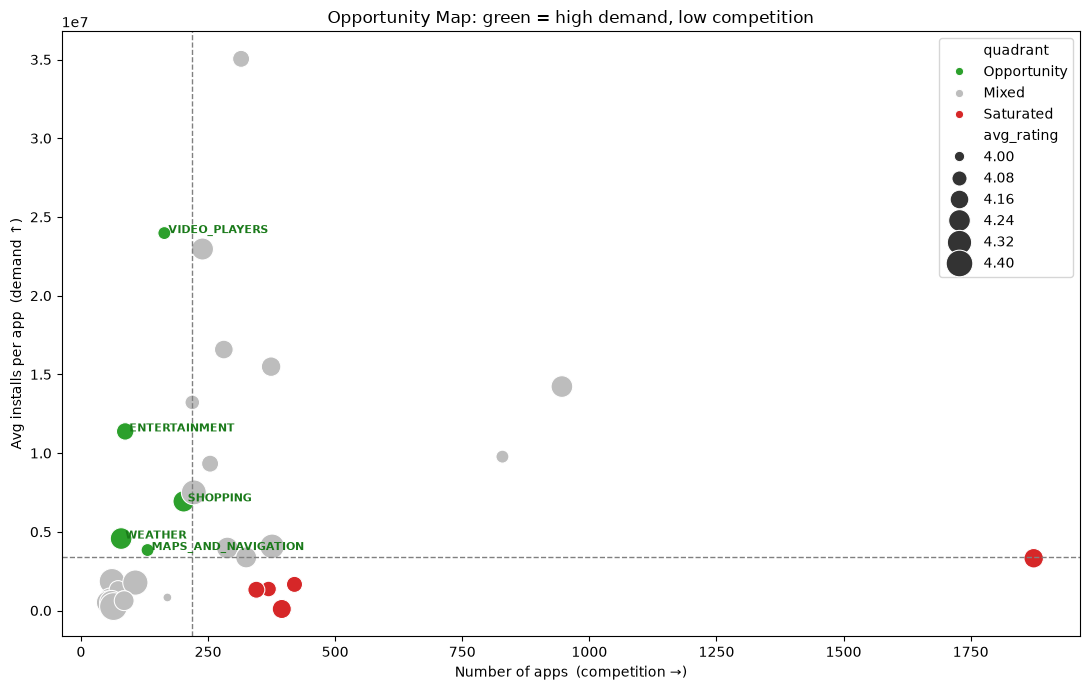

In [54]:
plt.figure(figsize=(11, 7))

sns.scatterplot(data=cat_ranked, x="num_apps", y="avg_installs",
                size="avg_rating", sizes=(40, 400),
                hue="quadrant",
                palette={"Opportunity": "#2ca02c",
                         "Saturated": "#d62728",
                         "Mixed": "#bdbdbd"})

# draw the quadrant boundaries the labels refer to
plt.axvline(cat_ranked["num_apps"].median(),     color="gray", ls="--", lw=1)
plt.axhline(cat_ranked["avg_installs"].median(), color="gray", ls="--", lw=1)

# green labels: every Opportunity category
for _, row in cat_ranked.iterrows():
    if row["quadrant"] == "Opportunity":
        plt.text(row["num_apps"] + 8, row["avg_installs"], row["Category"],
                 fontsize=8, color="#1a7a1a", fontweight="bold")

plt.title("Opportunity Map: green = high demand, low competition")
plt.xlabel("Number of apps  (competition →)")
plt.ylabel("Avg installs per app  (demand ↑)")
plt.tight_layout()
plt.show()

### What the map shows
Two stories jump out. **Communication, Social, and Video Players** sit high on
demand with relatively few apps — concentrated, winner-take-all markets where a
strong entrant can capture real traffic. At the opposite corner, **Family** is
the saturation warning: **1,876 apps** (the most of any category), yet the
typical Family app is small — a **3.3M average that's dragged up by a handful of
hits**. A newcomer there fights the most competitors for a shrinking slice of
traffic.